# Notebook 03 — Regression Results (Speed Prediction)

This notebook loads 10-fold CV regression results and produces:

1. **Ablation table** — RMSE / MAE / R² across GRF-only, Markers-only, Two-Tower
2. **Predicted vs actual scatter** — bias and variance per model
3. **Per-condition RMSE and bias** — which conditions are hardest to regress?
4. **Per-fold RMSE distribution** — variability across folds
5. **Attribution analysis** — which part of the gait cycle drives speed prediction?

Run `scripts/run_cv.py` for all three model variants before executing:
```bash
uv run python scripts/run_cv.py --task regression --subject-data data/raw/d_subjectData.csv --model grf_only --subsample-frac 0.25
uv run python scripts/run_cv.py --task regression --subject-data data/raw/d_subjectData.csv --model marker_only --subsample-frac 0.25
uv run python scripts/run_cv.py --task regression --subject-data data/raw/d_subjectData.csv --model two_tower --subsample-frac 0.25
```

> **Note:** Results in this notebook were generated with `--subsample-frac 0.25`
> (25% of cycles per subject/condition, stratified) due to memory constraints.
> `--n-folds 10` is the default.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader

sys.path.insert(0, str(Path.cwd().parent))

from gait_ml.dataset import (
    CONDITION_LABELS,
    GaitCycleDataset,
    add_speed_column,
    kfold_splits,
    load_manifest,
)
from gait_ml.models import (
    GRFOnlyRegressor,
    MarkerOnlyRegressor,
    TwoTowerRegressor,
)
from gait_ml.train import get_device

PROCESSED_DIR    = Path("../data/processed")
RESULTS_DIR      = Path("../results")
CKPT_DIR         = Path("../checkpoints")
SUBJECT_DATA_CSV = Path("../data/raw/d_subjectData.csv")

DEVICE  = get_device()
N_FOLDS = 10   # must match --n-folds used during training
print(f"Device: {DEVICE}")

COND_ORDER = [
    "walk_preferred", "walk_predetermined", "walk_froude",
    "run_predetermined", "run_froude_a", "run_froude_b",
]
COND_DISPLAY = {
    "walk_preferred":     "Walk\nPreferred",
    "walk_predetermined": "Walk\nFixed",
    "walk_froude":        "Walk\nFroude",
    "run_predetermined":  "Run\nFixed",
    "run_froude_a":       "Run\nFroude A",
    "run_froude_b":       "Run\nFroude B",
}
MODEL_DISPLAY = {
    "grf_only":    "GRF only",
    "marker_only": "Markers only",
    "two_tower":   "Two-Tower (fused)",
}
MODALITY_FOR_MODEL = {
    "grf_only":    "grf",
    "marker_only": "markers",
    "two_tower":   "both",
}
MODEL_CLASSES = {
    "grf_only":    GRFOnlyRegressor,
    "marker_only": MarkerOnlyRegressor,
    "two_tower":   TwoTowerRegressor,
}

sns.set_theme(style="whitegrid", font_scale=1.2)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Setup complete.")

Device: mps
Setup complete.


## 1. Load CV results

In [2]:
model_names = ["grf_only", "marker_only", "two_tower"]
results: dict[str, pd.DataFrame] = {}

for name in model_names:
    path = RESULTS_DIR / f"{N_FOLDS}fold_regression_{name}.csv"
    if path.exists():
        results[name] = pd.read_csv(path)
        print(f"{MODEL_DISPLAY[name]:25s}  {len(results[name])} folds")
    else:
        print(f"[missing] {path}")

assert results, (
    f"No results found — run scripts/run_cv.py "
    f"--task regression --n-folds {N_FOLDS} first."
)

GRF only                   10 folds
Markers only               10 folds
Two-Tower (fused)          10 folds


## 2. Ablation table

Mean ± std across CV folds.

In [3]:
rows = []
for name, df in results.items():
    rows.append({
        "Model":      MODEL_DISPLAY[name],
        "RMSE (m/s)": f"{df['rmse'].mean():.4f} ± {df['rmse'].std():.4f}",
        "MAE (m/s)":  f"{df['mae'].mean():.4f} ± {df['mae'].std():.4f}",
        "R²":         f"{df['r2'].mean():.3f} ± {df['r2'].std():.3f}",
        "N folds":    len(df),
    })

print(f"Ablation table ({N_FOLDS}-fold CV):")
print(pd.DataFrame(rows).set_index("Model").to_string())

Ablation table (10-fold CV):
                        RMSE (m/s)        MAE (m/s)             R²  N folds
Model                                                                      
GRF only           0.2347 ± 0.0411  0.1467 ± 0.0314  0.951 ± 0.016       10
Markers only       0.1101 ± 0.0374  0.0712 ± 0.0192  0.989 ± 0.007       10
Two-Tower (fused)  0.1120 ± 0.0303  0.0724 ± 0.0145  0.989 ± 0.005       10


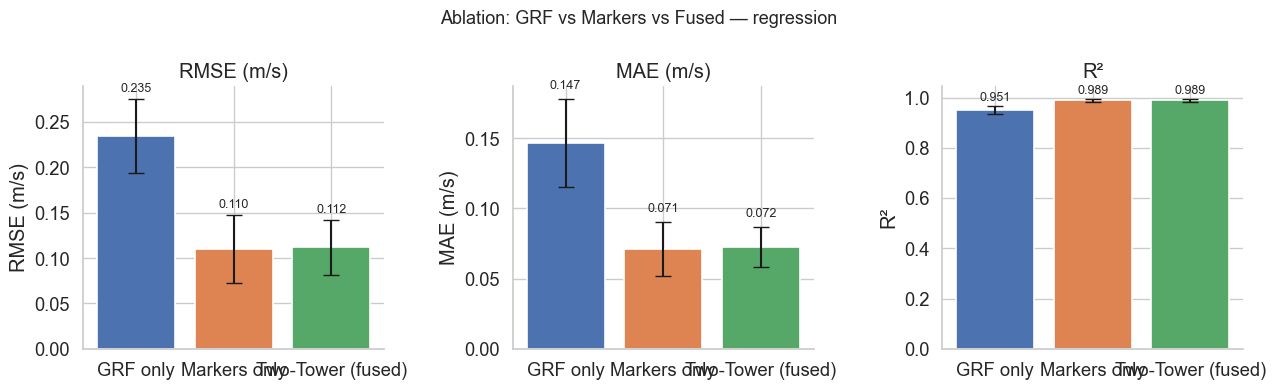

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names  = list(results.keys())
labels = [MODEL_DISPLAY[n] for n in names]
colors = ["#4C72B0", "#DD8452", "#55A868"]

metrics = [
    ("rmse", "RMSE (m/s)",  False),
    ("mae",  "MAE (m/s)",   False),
    ("r2",   "R²",          True),   # higher is better
]
for ax, (col, ylabel, higher_better) in zip(axes, metrics):
    means = [results[n][col].mean() for n in names]
    stds  = [results[n][col].std()  for n in names]
    bars  = ax.bar(labels, means, yerr=stds, capsize=6, color=colors,
                   edgecolor="white", linewidth=1.2, error_kw=dict(linewidth=1.5))
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + s + (0.005 if not higher_better else 0.01),
                f"{m:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)

fig.suptitle("Ablation: GRF vs Markers vs Fused — regression", fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_regression.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Predicted vs actual

Runs inference on each held-out subject using the saved checkpoints.
Points on the identity line = perfect prediction.

In [5]:
def collect_predictions(model_name: str) -> pd.DataFrame:
    """Run inference on every held-out fold; return (condition, true_speed, pred_speed)."""
    manifest = load_manifest(PROCESSED_DIR)
    manifest = add_speed_column(manifest, SUBJECT_DATA_CSV)
    manifest = manifest.dropna(subset=["speed_ms"]).reset_index(drop=True)
    folds = kfold_splits(manifest, N_FOLDS)
    modality = MODALITY_FOR_MODEL[model_name]
    rows = []

    for fold_idx, (_, test_df, _) in enumerate(folds):
        ckpt = CKPT_DIR / "regression" / model_name / f"fold_{fold_idx}" / "best.pt"
        if not ckpt.exists():
            print(f"  [skip] no checkpoint for fold_{fold_idx}")
            continue

        ds = GaitCycleDataset(test_df, PROCESSED_DIR, modality=modality, target="speed_ms")
        loader = DataLoader(ds, batch_size=256, shuffle=False)

        model = MODEL_CLASSES[model_name]()
        model.load_state_dict(torch.load(ckpt, weights_only=True, map_location=DEVICE))
        model = model.to(DEVICE).eval()

        cycle_idx = 0
        with torch.no_grad():
            for grf, markers, speeds in loader:
                preds = model(grf.to(DEVICE), markers.to(DEVICE)).cpu().numpy()
                trues = speeds.numpy()
                batch_meta = test_df.iloc[cycle_idx : cycle_idx + len(trues)]
                for i, (t, p) in enumerate(zip(trues, preds)):
                    rows.append({
                        "fold":       fold_idx,
                        "subject_id": batch_meta.iloc[i]["subject_id"],
                        "condition":  batch_meta.iloc[i]["condition"],
                        "true_speed": float(t),
                        "pred_speed": float(p),
                        "error":      float(p - t),
                    })
                cycle_idx += len(trues)

    return pd.DataFrame(rows)


pred_dfs: dict[str, pd.DataFrame] = {}
for name in [n for n in model_names if n in results]:
    print(f"Collecting predictions: {MODEL_DISPLAY[name]} ...", end=" ", flush=True)
    pred_dfs[name] = collect_predictions(name)
    print(f"done  ({len(pred_dfs[name])} cycles)")

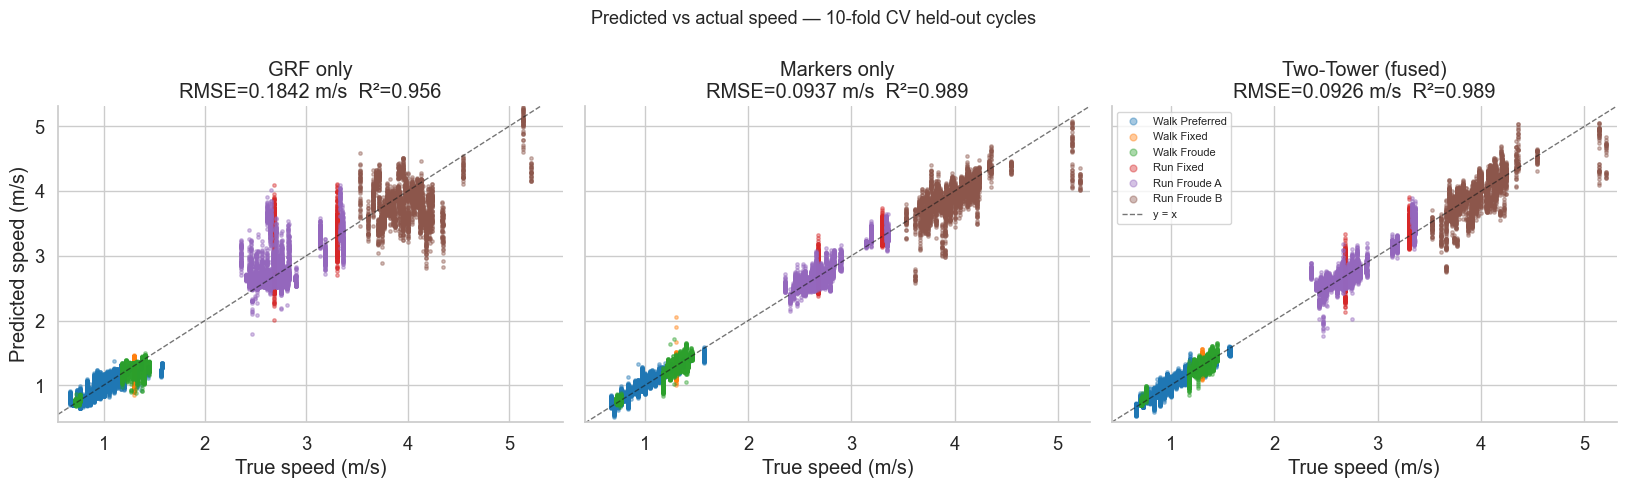

In [6]:
n_models = len(pred_dfs)
fig, axes = plt.subplots(1, n_models, figsize=(5.5 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

cond_palette = dict(zip(COND_ORDER, sns.color_palette("tab10", len(COND_ORDER))))

for ax, (name, df) in zip(axes, pred_dfs.items()):
    for cond in COND_ORDER:
        sub = df[df["condition"] == cond]
        if sub.empty:
            continue
        ax.scatter(sub["true_speed"], sub["pred_speed"],
                   s=6, alpha=0.4, color=cond_palette[cond],
                   label=COND_DISPLAY[cond].replace("\n", " "))

    lims = [df[["true_speed", "pred_speed"]].min().min() - 0.1,
            df[["true_speed", "pred_speed"]].max().max() + 0.1]
    ax.plot(lims, lims, "k--", linewidth=1, alpha=0.6, label="y = x")
    ax.set_xlim(lims); ax.set_ylim(lims)

    rmse = np.sqrt(np.mean(df["error"] ** 2))
    r2   = 1 - np.sum(df["error"] ** 2) / np.sum((df["true_speed"] - df["true_speed"].mean()) ** 2)
    ax.set_title(f"{MODEL_DISPLAY[name]}\nRMSE={rmse:.4f} m/s  R²={r2:.3f}")
    ax.set_xlabel("True speed (m/s)")
    ax.set_ylabel("Predicted speed (m/s)" if ax == axes[0] else "")
    if ax == axes[-1]:
        ax.legend(markerscale=2, fontsize=8, loc="upper left", framealpha=0.8)

fig.suptitle(f"Predicted vs actual speed — {N_FOLDS}-fold CV held-out cycles", fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Per-condition RMSE and bias

RMSE (magnitude of error) and bias (mean signed error, pred − true) per condition.
Blue bars = walking conditions, orange = running.

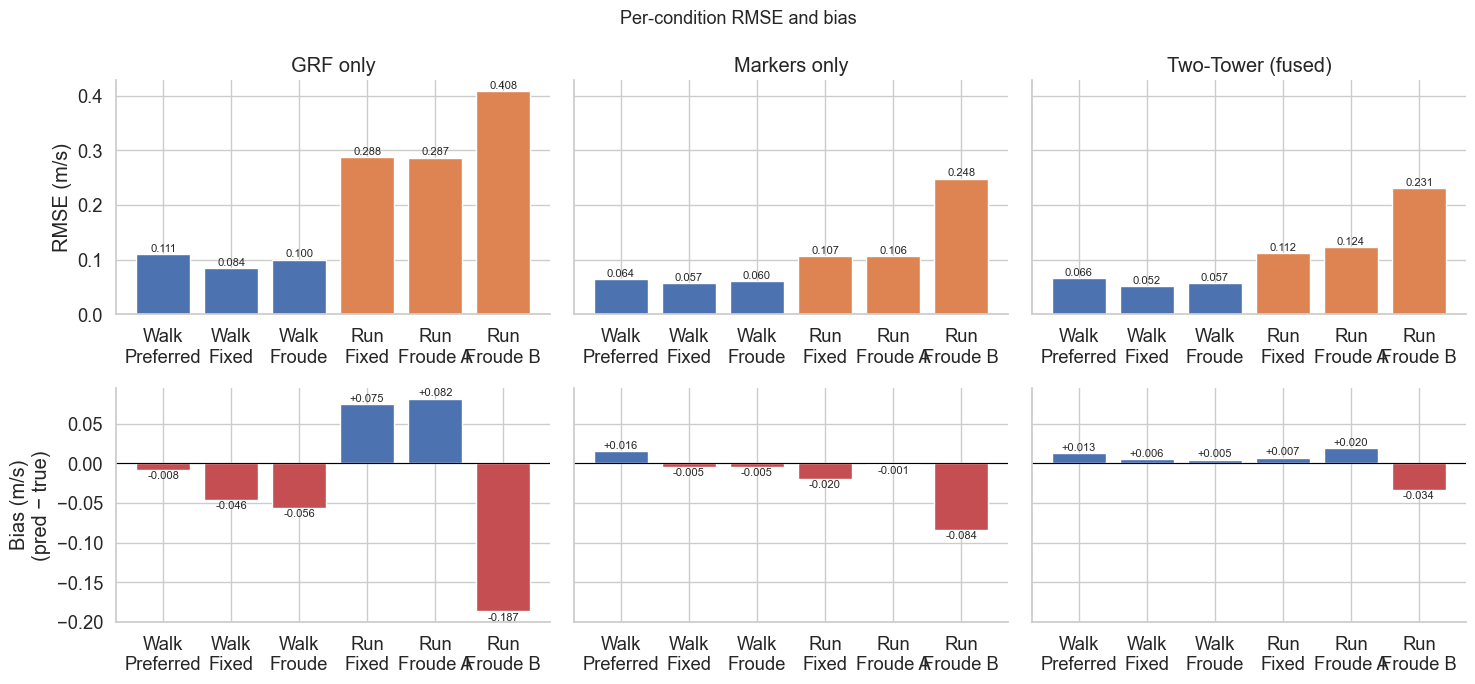

In [7]:
n_models = len(pred_dfs)
fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 7), sharey="row")
if n_models == 1:
    axes = axes.reshape(2, 1)

walk_run_colors = ["#4C72B0"] * 3 + ["#DD8452"] * 3

for col, (name, df) in enumerate(pred_dfs.items()):
    conds = [c for c in COND_ORDER if c in df["condition"].values]
    xlabels = [COND_DISPLAY[c] for c in conds]
    rmses  = [np.sqrt(np.mean(df[df["condition"] == c]["error"] ** 2)) for c in conds]
    biases = [df[df["condition"] == c]["error"].mean() for c in conds]

    # Row 0: RMSE
    ax = axes[0, col]
    bars = ax.bar(xlabels, rmses, color=walk_run_colors[:len(conds)], edgecolor="white")
    for bar, v in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f"{v:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(MODEL_DISPLAY[name])
    ax.set_ylabel("RMSE (m/s)" if col == 0 else "")

    # Row 1: Bias
    ax = axes[1, col]
    bar_colors = ["#4C72B0" if b >= 0 else "#C44E52" for b in biases]
    bars = ax.bar(xlabels, biases, color=bar_colors, edgecolor="white")
    ax.axhline(0, color="black", linewidth=0.8)
    for bar, v in zip(bars, biases):
        va = "bottom" if v >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, v + (0.001 if v >= 0 else -0.001),
                f"{v:+.3f}", ha="center", va=va, fontsize=8)
    ax.set_ylabel("Bias (m/s)\n(pred − true)" if col == 0 else "")

fig.suptitle("Per-condition RMSE and bias", fontsize=13)
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "regression_per_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Per-fold RMSE distribution

Variability across folds. High variance suggests the model generalises
well to some subjects but poorly to others.

/var/folders/r7/6qdg6hx128vf3nkqy015p1j00000gn/T/ipykernel_85596/2575956619.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x="Model", y="RMSE (m/s)",


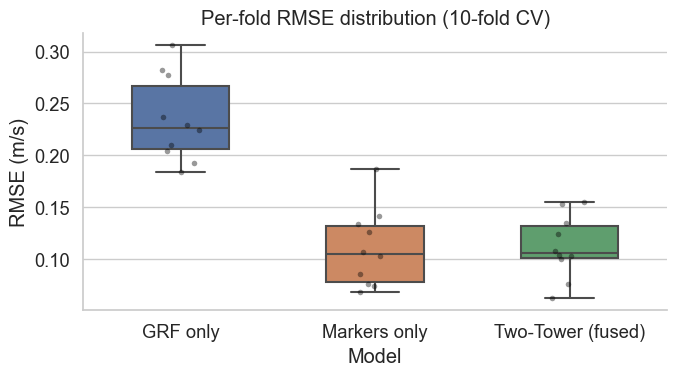

In [8]:
long_rows = []
for name, df in results.items():
    for _, row in df.iterrows():
        long_rows.append({"Model": MODEL_DISPLAY[name], "RMSE (m/s)": row["rmse"]})

long_df = pd.DataFrame(long_rows)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=long_df, x="Model", y="RMSE (m/s)",
            palette=["#4C72B0", "#DD8452", "#55A868"],
            width=0.5, linewidth=1.5, ax=ax)
sns.stripplot(data=long_df, x="Model", y="RMSE (m/s)",
              color="black", alpha=0.4, size=4, jitter=True, ax=ax)
ax.set_ylabel("RMSE (m/s)")
ax.set_title(f"Per-fold RMSE distribution ({N_FOLDS}-fold CV)")
sns.despine()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fold_distribution_regression.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Check | Expected |
|-------|----------|
| Overall RMSE | < 0.15 m/s for GRF-only (strong speed signal) |
| R² | > 0.95 if the model generalises well |
| Walk RMSE > Run RMSE | Likely — walking speeds vary more across subjects |
| Two-Tower ≤ GRF-only RMSE | Fusion should help or at worst match |

If walking condition errors are much larger than running, this reflects the
genuine ambiguity in the data — walk_preferred, walk_froude, and
walk_predetermined can be very close in m/s for many subjects.
That is the core motivation for the hierarchical model (Phase 2 next step).

## 6. Attribution analysis (Integrated Gradients)

Which part of the gait cycle drives the speed prediction?

Unlike classification, there is no target class — attributions are computed
with respect to the scalar speed output. High attribution at a time point means
the model is sensitive to that part of the waveform when estimating speed.

Biomechanically, you'd expect:
- **GRF:** loading rate and peak force (early stance, ~0–20%) to matter most,
  as these scale with speed
- **Markers:** push-off phase (late stance, ~40–60%) and swing clearance,
  which correlate with stride length and cadence

In [10]:
from captum.attr import IntegratedGradients

# Subsampling budget: max cycles drawn from each fold's test set.
# No per-class breakdown for regression, so we can afford a larger pool.
N_ATTR_CYCLES = 200

MARKER_SEGMENTS = {
    "Pelvis":      list(range(0, 4)),
    "Left thigh":  list(range(4, 8)),
    "Left shank":  list(range(8, 12)),
    "Left foot":   list(range(12, 17)),
    "Right thigh": list(range(17, 21)),
    "Right shank": list(range(21, 25)),
    "Right foot":  list(range(25, 30)),
}
GRF_CHANNEL_NAMES = ["Fz_L", "Fz_R", "Fz_total"]
TIME_AXIS = np.linspace(0, 100, 101)


def _ig_regression(model, grf, markers, modality):
    """Integrated gradients w.r.t. scalar speed output, active modality only.

    Same fix as classification: wrap model in a closure for single-modality
    models so Captum never tries to differentiate w.r.t. the unused input.
    """
    if modality == "grf":
        def fwd(g): return model(g, markers)
        attr_g = IntegratedGradients(fwd).attribute(
            grf, baselines=torch.zeros_like(grf),
            n_steps=25, internal_batch_size=32,
        )
        return attr_g.detach(), torch.zeros_like(markers)
    elif modality == "markers":
        def fwd(m): return model(grf, m)
        attr_m = IntegratedGradients(fwd).attribute(
            markers, baselines=torch.zeros_like(markers),
            n_steps=25, internal_batch_size=32,
        )
        return torch.zeros_like(grf), attr_m.detach()
    else:
        attr_g, attr_m = IntegratedGradients(model).attribute(
            inputs=(grf, markers),
            baselines=(torch.zeros_like(grf), torch.zeros_like(markers)),
            n_steps=25, internal_batch_size=32,
        )
        return attr_g.detach(), attr_m.detach()


def compute_speed_attributions(model_name: str) -> dict:
    """Integrated gradients w.r.t. scalar speed output, averaged over all CV folds."""
    manifest = load_manifest(PROCESSED_DIR)
    manifest = add_speed_column(manifest, SUBJECT_DATA_CSV)
    manifest = manifest.dropna(subset=["speed_ms"]).reset_index(drop=True)
    folds = kfold_splits(manifest, N_FOLDS)
    modality = MODALITY_FOR_MODEL[model_name]
    rng = np.random.default_rng(42)

    grf_attr_sum     = np.zeros((3,  101))
    marker_attr_sum  = np.zeros((90, 101))
    grf_input_sum    = np.zeros((3,  101))
    total = 0

    for fold_idx, (_, test_df, _) in enumerate(folds):
        ckpt = CKPT_DIR / "regression" / model_name / f"fold_{fold_idx}" / "best.pt"
        if not ckpt.exists():
            continue

        ds = GaitCycleDataset(test_df, PROCESSED_DIR, modality=modality, target="speed_ms")

        model = MODEL_CLASSES[model_name]()
        model.load_state_dict(torch.load(ckpt, weights_only=True, map_location="cpu"))
        model = model.eval()

        # Collect full fold into memory, then draw a random subsample.
        all_grf, all_markers = [], []
        with torch.no_grad():
            for grf_batch, marker_batch, _ in DataLoader(ds, batch_size=256, shuffle=False):
                all_grf.append(grf_batch)
                all_markers.append(marker_batch)
        all_grf     = torch.cat(all_grf)
        all_markers = torch.cat(all_markers)

        n_fold = len(all_grf)
        chosen = rng.choice(n_fold, size=min(N_ATTR_CYCLES, n_fold), replace=False)
        chosen = torch.from_numpy(chosen)

        grf_sub    = all_grf[chosen].requires_grad_(True)
        marker_sub = all_markers[chosen].requires_grad_(True)

        attr_grf, attr_markers = _ig_regression(model, grf_sub, marker_sub, modality)
        n = len(chosen)
        grf_attr_sum    += attr_grf.numpy().sum(axis=0)
        marker_attr_sum += attr_markers.numpy().sum(axis=0)
        grf_input_sum   += grf_sub.detach().numpy().sum(axis=0)
        total += n

    return {
        "grf":            grf_attr_sum    / max(total, 1),
        "markers":        marker_attr_sum / max(total, 1),
        "grf_mean_input": grf_input_sum   / max(total, 1),
    }


reg_attr_results: dict[str, dict] = {}
for name in [n for n in model_names if n in results]:
    print(f"Computing attributions: {MODEL_DISPLAY[name]} ...", end=" ", flush=True)
    reg_attr_results[name] = compute_speed_attributions(name)
    print("done")

Computing attributions: GRF only ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 200 equal to the number of examples.
  warnings.warn(


done
Computing attributions: Markers only ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 200 equal to the number of examples.
  warnings.warn(


done
Computing attributions: Two-Tower (fused) ... 

/Users/mariafox/Documents/GitHub/gait-ml/.venv/lib/python3.14/site-packages/captum/attr/_utils/batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 200 equal to the number of examples.
  warnings.warn(


done


### GRF attributions for speed prediction

The black line is the mean GRF waveform averaged across **all conditions** (walking and running combined) — regression has no per-class breakdown since the output is a single continuous speed value.

- **Blue fill**: this part of the waveform pushes the speed prediction **higher** (relative to a zero-force baseline)
- **Red fill**: this part of the waveform pushes the speed prediction **lower**

The predominantly red colouring means that, relative to the zero baseline, the presence of GRF signal generally suppresses the predicted speed. This is counterintuitive at first — faster running produces higher peak forces — but the integrated gradient baseline (zero force everywhere) does not represent any real gait pattern; the model has never been trained on it and cannot extrapolate cleanly. What the model actually responds to is the *shape and timing* of the waveform, not its absolute level. The small blue spike at initial contact (≈0–5%) in the GRF-only and Two-Tower models is biomechanically meaningful: the initial loading rate immediately after heel strike is one of the clearest speed indicators.

Note: The Markers-only model row is intentionally blank — it never sees GRF input.

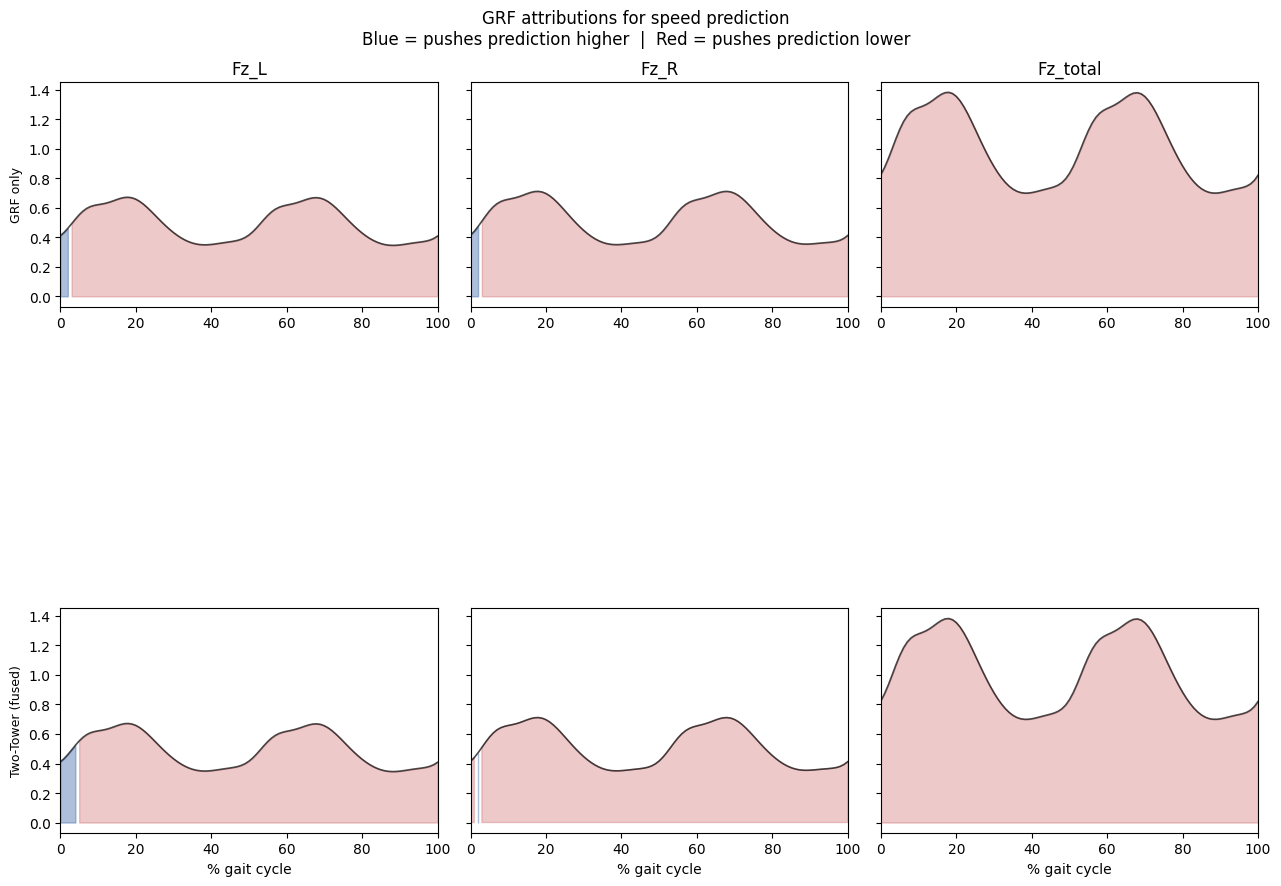

In [12]:
# GRF attribution overlaid on mean waveform
# One row per model, one column per GRF channel.
# Markers-only row is hidden — that model produces no GRF attributions.

n_models = len(reg_attr_results)
fig, axes = plt.subplots(n_models, 3, figsize=(13, 3 * n_models), sharey="row")
if n_models == 1:
    axes = axes.reshape(1, 3)

for row, (model_name, attrs) in enumerate(reg_attr_results.items()):
    for ch_idx, ch_name in enumerate(GRF_CHANNEL_NAMES):
        ax = axes[row, ch_idx]

        if MODALITY_FOR_MODEL[model_name] == "markers":
            # Markers-only model never sees GRF — hide axis cleanly
            ax.set_visible(False)
            continue

        waveform  = attrs["grf_mean_input"][ch_idx]
        attr      = attrs["grf"][ch_idx]
        scale     = np.abs(attr).max() or 1.0
        attr_norm = attr / scale

        ax.plot(TIME_AXIS, waveform, color="black", linewidth=1.2, alpha=0.7)
        ax.fill_between(TIME_AXIS, waveform, where=(attr_norm > 0),
                        alpha=0.45, color="#4C72B0", label="↑ speed")
        ax.fill_between(TIME_AXIS, waveform, where=(attr_norm < 0),
                        alpha=0.3,  color="#C44E52", label="↓ speed")
        ax.set_xlim(0, 100)
        if row == 0:
            ax.set_title(ch_name)
        if ch_idx == 0:
            ax.set_ylabel(MODEL_DISPLAY[model_name], fontsize=9)
        if row == n_models - 1:
            ax.set_xlabel("% gait cycle")

fig.suptitle("GRF attributions for speed prediction\n"
             "Blue = pushes prediction higher  |  Red = pushes prediction lower",
             fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "attr_grf_regression.png", dpi=150, bbox_inches="tight")
plt.show()

### Marker attributions for speed prediction

Same structure as the classification marker heatmaps, but attributions are averaged across all speed conditions rather than broken out by class. Rows = body segments (Pelvis → feet), columns = % gait cycle.

**What to look for:**
- **Left shank** (row 3) shows persistently high attribution throughout the cycle in both Markers-only and Two-Tower — shank kinematics encode speed through stride length and the rate of limb advancement
- Initial contact occurs at ≈0% and ≈50% (left and right foot). The attribution hotspots at ≈15–20% and ≈55–60% correspond to peak loading response and pre-swing push-off — the two moments where speed-dependent kinematic differences are largest
- The Two-Tower model shows slightly lower peak marker attributions than Markers-only, consistent with the GRF encoder sharing some of the predictive load

Note: The GRF-only model is excluded — its marker attributions are identically zero by design.

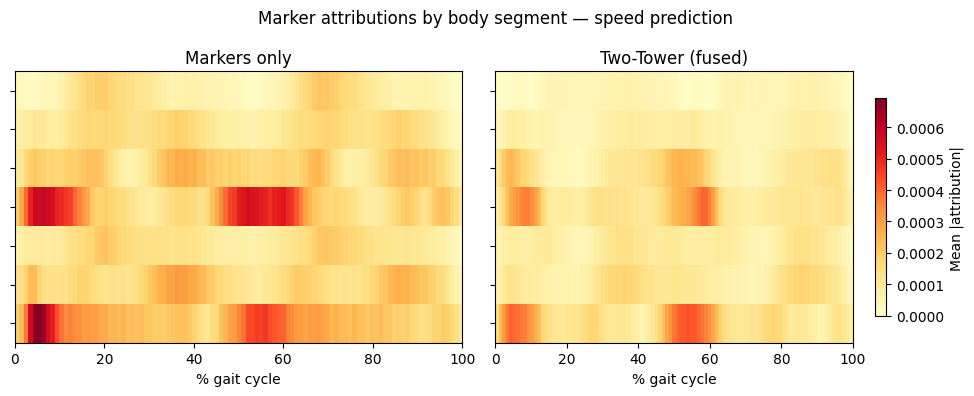

In [13]:
# Marker segment heatmap — only models that use marker input
seg_names = list(MARKER_SEGMENTS.keys())

all_seg_attr = []
for model_name, attrs in reg_attr_results.items():
    if MODALITY_FOR_MODEL[model_name] == "grf":
        continue  # GRF-only model has no marker attributions
    marker_attr = attrs["markers"]  # (90, 101)
    seg_attr = np.zeros((len(seg_names), 101))
    for s_idx, (_, marker_idxs) in enumerate(MARKER_SEGMENTS.items()):
        ch_idxs = [m * 3 + ax for m in marker_idxs for ax in range(3)]
        seg_attr[s_idx] = np.abs(marker_attr[ch_idxs]).mean(axis=0)
    all_seg_attr.append((model_name, seg_attr))

n_marker_models = len(all_seg_attr)
fig, axes = plt.subplots(1, n_marker_models, figsize=(5 * n_marker_models, 4), sharey=True)
if n_marker_models == 1:
    axes = [axes]

vmax = max(s.max() for _, s in all_seg_attr) if all_seg_attr else 1.0
for ax, (model_name, seg_attr) in zip(axes, all_seg_attr):
    im = ax.imshow(seg_attr, aspect="auto", origin="upper",
                   extent=[0, 100, len(seg_names) - 0.5, -0.5],
                   cmap="YlOrRd", vmin=0, vmax=vmax)
    ax.set_yticks(range(len(seg_names)))
    ax.set_yticklabels(seg_names if ax == axes[0] else [], fontsize=9)
    ax.set_xlabel("% gait cycle")
    ax.set_title(MODEL_DISPLAY[model_name])

if all_seg_attr:
    fig.colorbar(im, ax=axes[-1], label="Mean |attribution|", shrink=0.8)
fig.suptitle("Marker attributions by body segment — speed prediction", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "attr_markers_regression.png", dpi=150, bbox_inches="tight")
plt.show()